In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [3]:
data = pd.read_csv("intraday.csv", index_col = "time", parse_dates = ["time"])
data

,price
time,
2018-01-01 22:00:00+00:00,1.201205
2018-01-02 04:00:00+00:00,1.207055
2018-01-02 10:00:00+00:00,1.204440
2018-01-02 16:00:00+00:00,1.205800
2018-01-02 22:00:00+00:00,1.204690
...,...
2019-12-29 22:00:00+00:00,1.119920
2019-12-30 04:00:00+00:00,1.119940
2019-12-30 10:00:00+00:00,1.120095


In [4]:
data["returns"] = np.log(data.price.div(data.price.shift(1)))
data

,price,returns
time,,
2018-01-01 22:00:00+00:00,1.201205,NaN
2018-01-02 04:00:00+00:00,1.207055,0.004858
2018-01-02 10:00:00+00:00,1.204440,-0.002169
2018-01-02 16:00:00+00:00,1.205800,0.001129
2018-01-02 22:00:00+00:00,1.204690,-0.000921
...,...,...
2019-12-29 22:00:00+00:00,1.119920,0.002092
2019-12-30 04:00:00+00:00,1.119940,0.000018
2019-12-30 10:00:00+00:00,1.120095,0.000138


In [5]:
dev = 2
SMA = 30

<Axes: xlabel='time'>

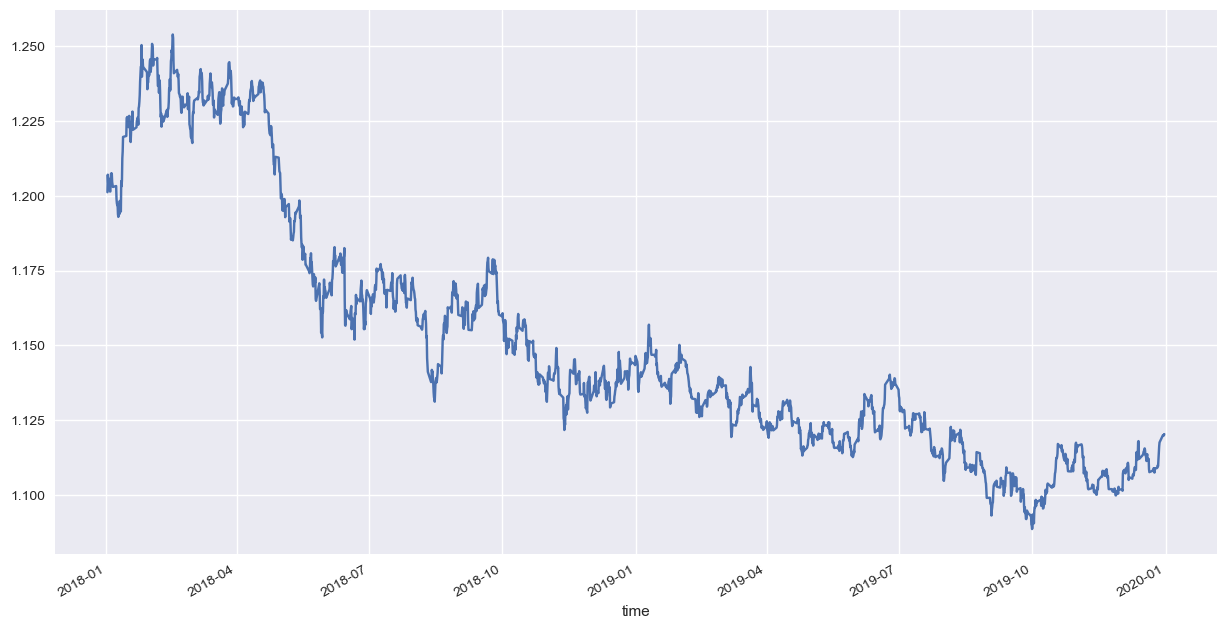

In [9]:
data.price.plot(figsize = (15,8))

In [10]:
data["SMA"] = data.price.rolling(SMA).mean()

<Axes: xlabel='time'>

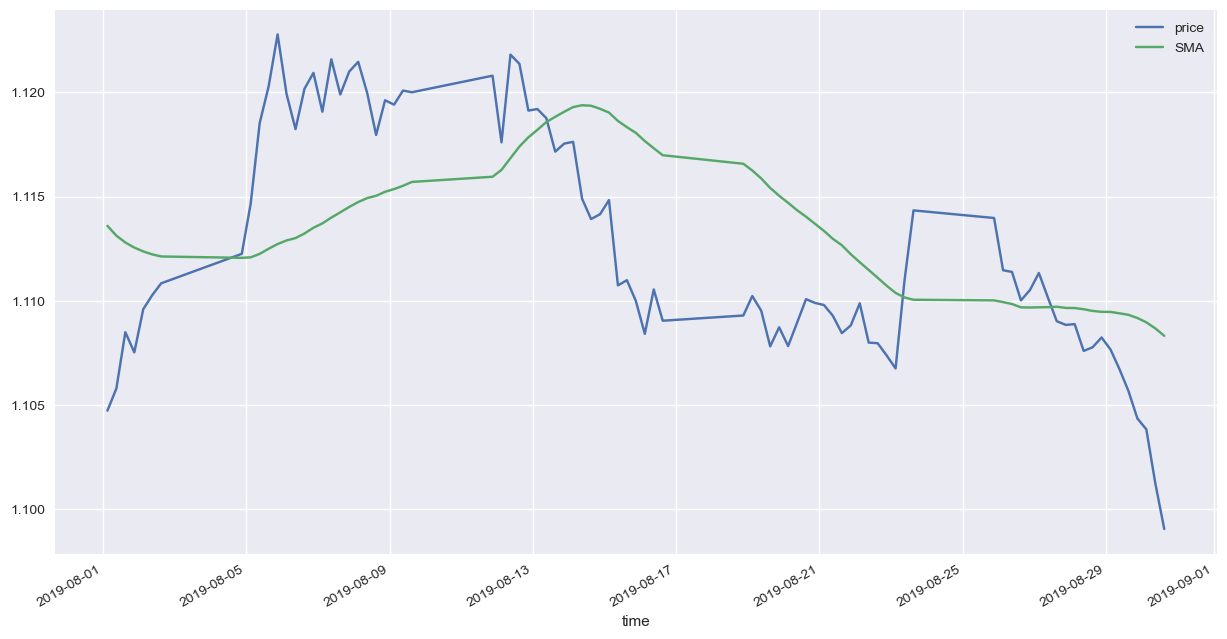

In [12]:
data[["price", "SMA"]].loc["2019-08"].plot(figsize = (15,8))

In [14]:
data["Upper"] = data.SMA + data.price.rolling(SMA).std()*dev
data["Lower"] = data.SMA - data.price.rolling(SMA).std()*dev
data

,price,returns,SMA,Upper,Lower
time,,,,,
2018-01-01 22:00:00+00:00,1.201205,NaN,NaN,NaN,NaN
2018-01-02 04:00:00+00:00,1.207055,0.004858,NaN,NaN,NaN
2018-01-02 10:00:00+00:00,1.204440,-0.002169,NaN,NaN,NaN
2018-01-02 16:00:00+00:00,1.205800,0.001129,NaN,NaN,NaN
2018-01-02 22:00:00+00:00,1.204690,-0.000921,NaN,NaN,NaN
...,...,...,...,...,...
2019-12-29 22:00:00+00:00,1.119920,0.002092,1.111391,1.117567,1.105215
2019-12-30 04:00:00+00:00,1.119940,0.000018,1.111553,1.118352,1.104754
2019-12-30 10:00:00+00:00,1.120095,0.000138,1.111777,1.119235,1.104318


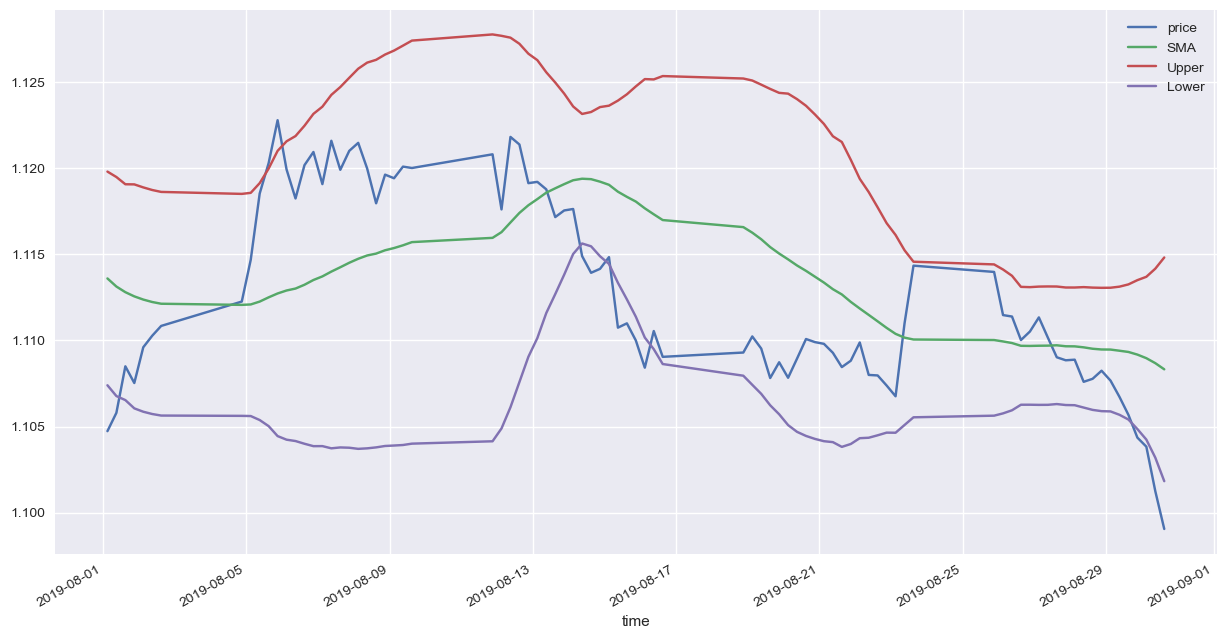

In [16]:
data[["price", "SMA", "Upper", "Lower"]].loc["2019-08"].plot(figsize = (15,8))
plt.show()

In [17]:
data.dropna(inplace = True)

In [18]:
data

,price,returns,SMA,Upper,Lower
time,,,,,
2018-01-11 04:00:00+00:00,1.194770,-0.000498,1.200504,1.210160,1.190849
2018-01-11 10:00:00+00:00,1.204915,0.008455,1.200628,1.210415,1.190841
2018-01-11 16:00:00+00:00,1.203205,-0.001420,1.200500,1.210035,1.190964
2018-01-11 22:00:00+00:00,1.205165,0.001628,1.200524,1.210104,1.190943
2018-01-12 04:00:00+00:00,1.212530,0.006093,1.200748,1.211122,1.190374
...,...,...,...,...,...
2019-12-29 22:00:00+00:00,1.119920,0.002092,1.111391,1.117567,1.105215
2019-12-30 04:00:00+00:00,1.119940,0.000018,1.111553,1.118352,1.104754
2019-12-30 10:00:00+00:00,1.120095,0.000138,1.111777,1.119235,1.104318


# Creating OOP

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [57]:
class MeanRev_bt():
    def __init__(self, symbol, SMA, dev, start, end, tc = 0):
        self._symbol = symbol
        self._SMA = SMA
        self._dev = dev
        self._start = start
        self._end = end
        self._tc = tc
        self.get_data()
        self.prepare_data()

        
    def __repr__(self):
        return "Mean Reversion Backtesting symbol = {} with SMA = {}, dev = {}, start = {}, end = {}, tc = {}".format(self._symbol, self._SMA, self._dev, self._start, self._end, self._tc)

    def get_data(self):
        raw = pd.read_csv("intraday_pairs.csv", index_col = "time", parse_dates = ["time"])
        raw = raw.loc[self._start : self._end, self._symbol].to_frame()
        raw.rename(columns = {self._symbol : "price"}, inplace = True)
        raw["returns"] = np.log(raw.price.div(raw.price.shift(1)))
        raw["creturns"] = raw.returns.cumsum().apply(np.exp)
        self.data = raw.copy().dropna()

    def prepare_data(self):
        data = self.data.copy()
        data["SMA"] = data.price.rolling(self._SMA).mean()
        data["Upper"] = data.SMA + data.price.rolling(self._SMA).std()*self._dev
        data["Lower"] = data.SMA - data.price.rolling(self._SMA).std()*self._dev
        self.data = data.copy().dropna()


    def set_parameters(self, SMA = None, dev = None):
        if SMA is not None:
            self._SMA = SMA
            self.data["SMA"] = self.data.price.rolling(self._SMA).mean()
            self.data["Upper"] = self.data.SMA + self.data.price.rolling(self._SMA).std()*self._dev
            self.data["Lower"] = self.data.SMA - self.data.price.rolling(self._SMA).std()*self._dev
        if dev is not None:
            self._dev = dev 
            self.data["Upper"] = self.data.SMA + self.data.price.rolling(self._SMA).std()*self._dev
            self.data["Lower"] = self.data.SMA - self.data.price.rolling(self._SMA).std()*self._dev
        
    def test_strategy(self):
        data = self.data.copy()
        data["position"] = np.where(data.price < data.Lower, 1, np.nan) # open Long if price < Lower band (OverSold)
        data["position"] = np.where(data.price > data.Upper, -1, data["position"]) # open Short if price > Upper band (OverBought)
            
        data["distance"] = data.price - data.SMA
        data["position"] = np.where(data.distance * data.distance.shift(1) < 0, 0, data["position"])
        data["position"] = data.position.ffill().fillna(0)

        data["strategy"] = data.returns * data.position.shift(1)
        data["trades"] = data.position.diff().abs()
        data["cstrategy"] = data.strategy.cumsum().apply(np.exp) - data.trades*self._tc
        self.result = data.copy().dropna()
        
        perf = data.cstrategy.iloc[-1]
        out_perf = perf - data.creturns.iloc[-1]
        return round(perf, 3), round(out_perf, 3)
        
    def plot_result(self):
        if self.result is None:
            print("Please run test_strategy() first!")
        else:
            data = self.result.copy()
            data[["creturns", "cstrategy"]].plot(figsize = (15,8))
            plt.title("{} | SMA = {} | dev = {} | tc = {}".format(self._symbol, self._SMA, self._dev, self._tc), fontsize = 12)
            plt.show()
            

    def optimize_strat(self, SMA_range, dev_range):

        comb = list(product(range(*SMA_range), range(*dev_range)))
        result = []

        for i in comb:
            self.set_parameters(i[0], i[1])
            result.append(self.test_strategy()[0])

        best_perf = np.max(result)
        opt = comb[np.argmax(result)]

        #Set/Run optimize strategy
        self.set_parameters(opt[0], opt[1])
        self.test_strategy()

        many_results = pd.DataFrame(data = comb, columns = ["SMA", "dev"])
        many_results["performance"] = result
        self.result_overview = many_results

        return opt, best_perf
        



















    

In [58]:
test = MeanRev_bt("EURUSD",30 , 2, "2018-01-01", "2019-12-30")

In [52]:
test

Mean Reversion Backtesting symbol = EURUSD with SMA = 30, dev = 2, start = 2018-01-01, end = 2019-12-30, tc = 0

In [34]:
test.data

,price,returns,creturns,SMA,Upper,Lower
time,,,,,,
2018-01-11 10:00:00+00:00,1.204915,0.008455,1.003089,1.200628,1.210415,1.190841
2018-01-11 16:00:00+00:00,1.203205,-0.001420,1.001665,1.200500,1.210035,1.190964
2018-01-11 22:00:00+00:00,1.205165,0.001628,1.003297,1.200524,1.210104,1.190943
2018-01-12 04:00:00+00:00,1.212530,0.006093,1.009428,1.200748,1.211122,1.190374
2018-01-12 10:00:00+00:00,1.214820,0.001887,1.011334,1.201086,1.212589,1.189583
...,...,...,...,...,...,...
2019-12-29 22:00:00+00:00,1.119920,0.002092,0.931679,1.111391,1.117567,1.105215
2019-12-30 04:00:00+00:00,1.119940,0.000018,0.931695,1.111553,1.118352,1.104754
2019-12-30 10:00:00+00:00,1.120095,0.000138,0.931824,1.111777,1.119235,1.104318


In [35]:
test.plot_result()

AttributeError: 'MeanRev_bt' object has no attribute 'result'

In [36]:
test.test_strategy()

(np.float64(1.086), np.float64(0.154))

In [59]:
test.optimize_strat((1,20), (1,3))

((19, 2), np.float64(1.035))

In [63]:
test.test_strategy()

(np.float64(1.035), np.float64(0.103))

In [61]:
test.test_strategy()[0]

np.float64(1.035)

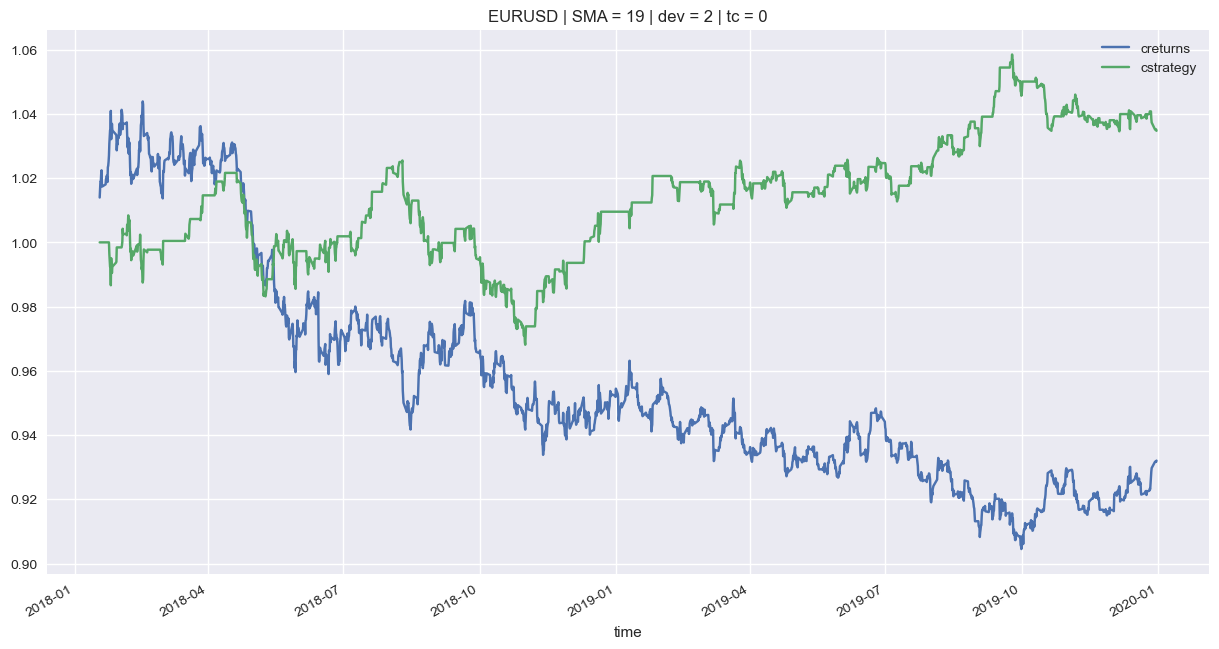

In [62]:
test.plot_result()